In [ ]:
# Import all necessary libraries for data analysis and statistics
import numpy as np  # for numerical operations and arrays
import pandas as pd  # for data manipulation with dataframes
import scipy  # for scientific computing
from scipy import stats  # for statistical tests
from scipy.stats import norm, t, binom, poisson, expon, chi2, f  # specific probability distributions
import matplotlib.pyplot as plt  # for creating visualizations
import seaborn as sns  # for enhanced statistical plots
import statsmodels  # for statistical modeling

#
# 1) One-Hot Encoding
#    - Description: Creates binary/dummy columns for each category (0/1).
#    - When to use: For nominal categories with no natural order; avoid when
#      cardinality is very high unless you reduce dimensions first.
#
# 2) Label Encoding
#    - Description: Maps categories to integer labels (0,1,2,...).
#    - When to use: For ordinal features or with tree-based models that can
#      handle integer categories; avoid for nominal features with linear models.
#
# 3) Ordinal Encoding
#    - Description: Encodes categories as integers according to a specified order.
#    - When to use: When categories have a meaningful order (e.g., low<med<high).
#
# 4) Frequency / Count Encoding
#    - Description: Replaces categories with their frequency or count in the data.
#    - When to use: Useful for high-cardinality features where one-hot would create
#      too many columns and a compact numeric representation is preferred.
#
# 5) Target / Mean Encoding
#    - Description: Replaces categories with a target-based statistic (e.g., mean).
#    - When to use: Can be powerful for predictive tasks but requires careful
#      handling (smoothing, cross-validation) to prevent target leakage and overfitting.
#
# 6) Binary / Hash / BaseN Encoding
#    - Description: Compact encodings that convert categories to binary/base-N
#      representations or hashed feature indices.
#    - When to use: When reducing dimensionality is important or when handling
#      streaming/unseen categories; hashing trades interpretability for fixed size.
#
# 7) Embedding Representations (deep learning)
#    - Description: Learns dense vector representations for categories using an
#      embedding layer or similar approach.
#    - When to use: For very high-cardinality categorical variables in neural
#      network models where learned representations improve performance.
#
# Practical considerations:
#  - Avoid the dummy variable trap with linear models (drop one dummy column).
#  - Handle unseen categories in production by mapping them to a special value
#    or using encoders that support unknown categories to avoid runtime errors.
#  - Group rare categories into an 'Other' bucket when sample counts are low.
#  - Scale or normalize numeric encodings if the downstream model expects scaled inputs.
#  - Choose simpler encodings for small datasets/models; test target/embedding
#    approaches for large/high-cardinality problems with proper validation.

In [2]:
# Create scatter plot showing relationship between total bill and tip
# hue colors points by smoker status, style changes marker by sex, size changes marker size by party size

sns.scatterplot(x=df.total_bill, y=df.tip, hue=df.smoker, style=df.sex, size=df['size'])plt.show()  # display the plot

SyntaxError: invalid syntax (2890013760.py, line 4)

In [ ]:
# Calculate correlation matrix for all numeric columns (shows how features relate to each other)
mat1 = df.corr(numeric_only=True)  # numeric_only=True ignores categorical columns
mat1  # display the correlation matrix

# Note: All correlations are positive, meaning when one variable increases, others also increase
# No negative correlations (inverse relationships) found in this dataset

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

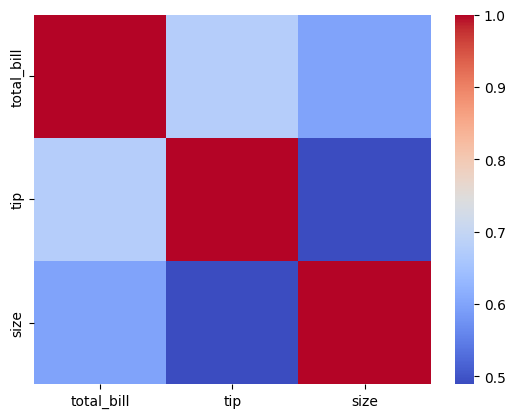

In [ ]:
# Visualize correlation matrix as a heatmap (red=strong positive, blue=strong negative)
sns.heatmap(mat1, cmap='coolwarm')  # coolwarm color scheme makes patterns easier to see

In [ ]:
# Next: We'll explore covariance (how two variables vary together)
# and coefficient of variation (ratio of std deviation to mean)

In [ ]:
# Import numpy for numerical operations (if not already imported)
import numpy as np

In [ ]:
# Create two sample arrays to demonstrate covariance and correlation calculations
x1 = np.array([4, 5, 3, 7, 8, 9])  # first variable
x2 = np.array([2, 9, 7, 4, 3, 6])  # second variable

In [ ]:
# Calculate covariance matrix (measures how x1 and x2 vary together)
np.cov(x1, x2)  # returns 2x2 matrix with variances on diagonal and covariances off-diagonal

array([[ 5.6       , -1.2       ],
       [-1.2       ,  6.96666667]])

In [ ]:
# Calculate sample variance of x1 (ddof=1 for sample variance instead of population)
np.var(x1, ddof=1)  # ddof=1 divides by (n-1) instead of n

np.float64(5.6)

In [ ]:
# Calculate sample variance of x2
np.var(x2, ddof=1)  # measures spread of data around the mean

np.float64(6.966666666666666)

In [ ]:
# Manually calculate covariance using formula: Σ[(x1 - mean(x1)) * (x2 - mean(x2))] / (n-1)
(sum(x1 - np.mean(x1)) * (x2 - np.mean(x2))) / (len(x1) - 1)  # should match np.cov() result

array([-0.,  0.,  0., -0., -0.,  0.])

In [ ]:
# Verify manual covariance calculation (same as above, confirming the formula)
(sum(x1 - np.mean(x1)) * (x2 - np.mean(x2))) / (len(x1) - 1)

array([-0.,  0.,  0., -0., -0.,  0.])

In [ ]:
# Calculate Pearson correlation coefficient (ranges from -1 to +1)
scipy.stats.pearsonr(x1, x2)  # measures linear relationship strength; returns (correlation, p-value)

PearsonRResult(statistic=np.float64(-0.19212094618518188), pvalue=np.float64(0.7153642167762257))

In [ ]:
# Manually calculate correlation: covariance / (std_x1 * std_x2)
-1.2 / (np.std(x1, ddof=1) * np.std(x2, ddof=1))  # should match pearsonr() result

np.float64(-0.19212094618518186)

In [ ]:
# Create new sample data to demonstrate coefficient of variation
w1 = [3, 8, 6, 3, 6, 8, 9, 7, 6]  # sample data with smaller values
w2 = [60, 65, 67, 68, 71, 73, 58, 73, 60]  # sample data with larger values

In [ ]:
# Calculate standard deviation of w1 (ddof=1 for sample std dev)
np.std(w1, ddof=1)  # measures spread/dispersion of data

np.float64(2.1081851067789197)

In [ ]:
# Calculate standard deviation of w2
np.std(w2, ddof=1)  # compare with w1 to see which has more variability

np.float64(5.754225500544022)

In [ ]:
# Calculate mean (average) of w1
np.mean(w1)  # central tendency of the data

np.float64(6.222222222222222)

In [ ]:
# Calculate mean of w2
np.mean(w2)  # note: w2 has larger mean than w1

np.float64(66.11111111111111)

In [ ]:
# Import libraries needed for regression analysis
import statsmodels.api as sm  # for statistical models like OLS regression
from statsmodels.formula.api import ols  # for formula-based OLS regression
import statsmodels.stats.multicomp  # for multiple comparison tests
import sklearn  # machine learning library
from sklearn.model_selection import train_test_split  # to split data into train/test sets

In [ ]:
import pandas as pd  # for working with dataframes
import os  # for operating system operations
# Change working directory to where our data files are located
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')
import matplotlib.pyplot as plt  # for creating plots

In [ ]:
# Load the 'faithful' dataset from Excel (Old Faithful geyser data)
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='faithful')

In [ ]:
# Display first 5 rows to see the data structure
df.head()  # shows eruption duration and waiting time between eruptions

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [ ]:
# Extract eruption duration column (our dependent/response variable)
erupt = df.eruptions

In [ ]:
# Extract waiting time column (our independent/predictor variable)
wait = df.waiting

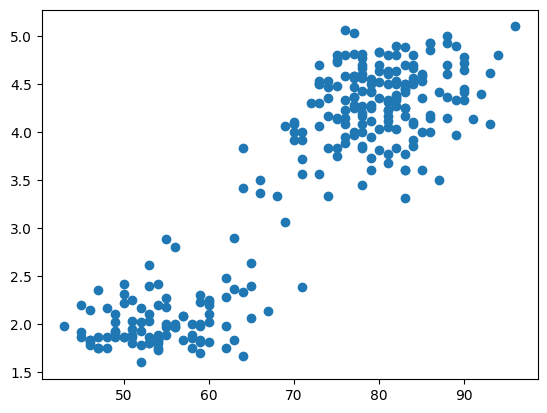

In [ ]:
# Create scatter plot to visualize relationship between waiting time and eruption duration
plt.scatter(wait, erupt)  # x=waiting time, y=eruption duration
plt.show()  # display the plot

In [ ]:
# Calculate Pearson correlation to measure strength of linear relationship
scipy.stats.pearsonr(wait, erupt)  # high positive correlation expected (longer wait = longer eruption)

PearsonRResult(statistic=np.float64(0.9008111683218131), pvalue=np.float64(8.129958506617982e-100))

In [ ]:
# Split data into training (75%) and testing (25%) sets

# X = waiting time (predictor), y = eruptions (target))  # random_state=20 ensures reproducible split

x_train, x_test, y_train, y_test = train_test_split(    df.waiting, df.eruptions, random_state=20, test_size=0.25

In [ ]:
# Check shape of training features (number of samples)
x_train.shape  # should be 75% of total data

(204,)

In [ ]:
# Check shape of training target variable
y_train.shape  # should match x_train shape

(204,)

In [ ]:
# Check shape of test features (number of samples)
x_test.shape  # should be 25% of total data

(68,)

In [ ]:
# Check shape of test target variable
y_test.shape  # should match x_test shape

(68,)

In [ ]:
# Display first few rows of training data to verify the split
x_train.head()

21     47
1      54
84     73
147    49
148    96
Name: waiting, dtype: int64

In [ ]:
# Note: We need to add a constant (intercept) term to the model
# The intercept represents the predicted value when waiting time = 0

In [ ]:
# Add constant term (intercept) to training data
x_train = sm.add_constant(x_train, prepend=False)  # prepend=False adds constant at end
# Fit OLS (Ordinary Least Squares) regression model

mod1 = sm.OLS(y_train, x_train).fit()  # predicts eruption duration from waiting timeprint(mod1.summary())
# Display detailed regression results (R-squared, coefficients, p-values, etc.)

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     804.1
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.34e-72
Time:                        12:52:41   Log-Likelihood:                -153.37
No. Observations:                 204   AIC:                             310.7
Df Residuals:                     202   BIC:                             317.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0770      0.003     28.357      0.0

In [ ]:
# Create new data for prediction: waiting times of 60 and 80 minutes
mydata = pd.DataFrame([[60, 1], [80, 1]], columns=['waiting', 'const'])  # const=1 for intercept

In [ ]:
# Display the prediction data
mydata  # shows waiting times and constant column

,waiting,const
0,60,1
1,80,1


In [ ]:
# Use fitted model to predict eruption durations for the new waiting times
mod1.predict(mydata)  # returns predicted eruption durations

0    2.628886
1    4.168843
dtype: float64

##### multiple linear regression

In [ ]:
# Load stackloss dataset for multiple linear regression (predicting stack loss from multiple variables)
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='stackloss')

In [ ]:
# View the stackloss data to understand features
df.head()  # contains Air.Flow, Water.Temp, Acid.Conc., and StackLoss

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18


In [ ]:
# Load stackloss data
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='stackloss')
# Split into training (85%) and test (15%) sets; X = all columns except StackLoss, y = StackLoss
x_train, x_test, y_train, y_test = train_test_split(
    df.drop('StackLoss', axis=1), df.StackLoss, random_state=20, test_size=0.15
)

# Add intercept termprint(mod1.summary())

x_train = sm.add_constant(x_train, prepend=False)# Display results showing effect of each predictor on stack loss

# Fit multiple linear regression model (multiple predictors → one outcome)mod1 = sm.OLS(y_train, x_train).fit()

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     43.81
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           4.66e-07
Time:                        12:52:41   Log-Likelihood:                -43.635
No. Observations:                  17   AIC:                             95.27
Df Residuals:                      13   BIC:                             98.60
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.6961      0.157      4.441      0.0

In [ ]:
# Load salaries dataset to analyze how gender and experience affect salary
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='salaries')

In [ ]:
# Select only columns of interest: years of service, gender, and salary
my_df = df[['yrs_service', 'gender', 'salary']]

In [ ]:
# Display first few rows of selected columns
my_df.head()

,yrs_service,gender,salary
0,18,Male,139750
1,16,Male,173200
2,3,Male,79750
3,39,Male,115000
4,41,Male,141500


In [ ]:
# Convert gender (categorical) to dummy variable: 0=Female, 1=Male
gen_dummy = pd.get_dummies(my_df.gender, drop_first=True).astype(int)  # drop_first avoids dummy variable trap
gen_dummy.head()  # show the binary encoding

,Male
0,1
1,1
2,1
3,1
4,1


In [ ]:
# Remove original gender column (we'll use the dummy variable instead)
my_df = my_df.drop('gender', axis=1)

In [ ]:
# Add the gender dummy variable to the dataframe
my_df = pd.concat([my_df, gen_dummy], axis=1)  # axis=1 adds as new column

In [ ]:
# View updated dataframe with Male dummy variable
my_df.head()  # now has yrs_service, salary, and Male (0 or 1)

,yrs_service,salary,Male
0,18,139750,1
1,16,173200,1
2,3,79750,1
3,39,115000,1
4,41,141500,1


In [ ]:
# Check unique values in Male column (should be 0 and 1)
np.unique([my_df.Male])  # verify binary encoding worked correctly

array([0, 1])

In [ ]:
# Check original gender categories in full dataset
np.unique(df['gender'])  # shows 'Female' and 'Male'

array(['Female', 'Male'], dtype=object)

In [ ]:
# Check rank categories (for later analysis)
np.unique(df['rank'])  # shows different academic ranks

array(['AssocProf', 'AsstProf', 'Prof'], dtype=object)

In [ ]:
# Split data: X = years of service + Male dummy, y = salary
x_train, x_test, y_train, y_test = train_test_split(
    my_df.drop('salary', axis=1), my_df.salary, random_state=20, test_size=0.1

)mod1 = sm.OLS(y_train, x_train).fit()  # fit regression model
x_train = sm.add_constant(x_train, prepend=False)  # add intercept

In [ ]:
# Display results showing how gender affects salary (controlling for experience)
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     26.31
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.22e-11
Time:                        12:52:43   Log-Likelihood:                -4165.1
No. Observations:                 357   AIC:                             8336.
Df Residuals:                     354   BIC:                             8348.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service   774.6347    117.519      6.592      

In [ ]:
# Interpretation: Males earn approximately $10,180 more than females on average,
# holding years of service constant (this is the coefficient for the Male dummy variable)
# Reference category is Female (Male=0), so Male coefficient shows the difference

In [ ]:
# Select columns for analyzing how academic rank affects salary
my_df = df[['yrs_service', 'rank', 'salary']]

In [ ]:
# Split data into train/test sets
x_train, x_test, y_train, y_test = train_test_split(
    my_df.drop('salary', axis=1), my_df.salary, random_state=20, test_size=0.1
)

# Convert rank (categorical with 3+ levels) to dummy variables
rank_train_dummy = pd.get_dummies(x_train['rank'], drop_first=True).astype(int)  # creates multiple dummies
x_train = x_train.drop('rank', axis=1)  # remove original rank column
x_train = pd.concat([x_train, rank_train_dummy], axis=1)  # add rank dummies

mod1 = sm.OLS(y_train, x_train).fit()  # fit model with rank effects
x_train = sm.add_constant(x_train, prepend=False)  # add intercept

In [ ]:
# Display regression results with rank coefficients
print(mod1.summary())  # shows salary differences across academic ranks

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     76.20
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           5.03e-38
Time:                        12:52:48   Log-Likelihood:                -4100.7
No. Observations:                 357   AIC:                             8209.
Df Residuals:                     353   BIC:                             8225.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service  -102.3938    121.964     -0.840      

In [ ]:
# Example hypothesis test: H₀: changing rank from AssocProf to Prof has no effect on salary (β=0)
# If p-value < 0.05, reject H₀ (rank change significantly affects salary)

In [ ]:
# General hypothesis testing steps:
# 1. State H₀ (null hypothesis: coefficient = 0, no effect)
# 2. Check p-value in regression output
# 3. If p < 0.05, reject H₀ (predictor is significant)
# 4. Interpret coefficient (positive = increases salary, negative = decreases)

In [ ]:
# Import StandardScaler to normalize features (mean=0, std=1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  # create scaler object
# Split stackloss data
x_train, x_test, y_train, y_test = train_test_split(

    df.drop('StackLoss', axis=1), df.StackLoss, test_size=0.1, random_state=20x_test = scaler.transform(x_test)  # use same mean/std from training

)# Transform test data using training parameters (avoid data leakage)

# Fit scaler on training data and transform (learn mean/std, then scale)x_train = scaler.fit_transform(x_train)  # now all features have mean=0, std=1

KeyError: "['StackLoss'] not found in axis"

In [ ]:
# Different techniques to handle categorical data (summary and examples)
#
# 1) One-Hot Encoding
#    - Creates binary/dummy columns for each category (0/1).
#    - Use when categories are nominal (no natural order).
#    - Beware of high cardinality (many columns); consider
#      dimensionality reduction or other encodings for those cases.
#    - pandas example:
#        pd.get_dummies(df['col'], prefix='col', drop_first=False)
#    - sklearn example (keeps column transformer friendly):
#        from sklearn.preprocessing import OneHotEncoder
#        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
#
# 2) Label Encoding
#    - Maps categories to integer labels (0,1,2,...).
#    - Use for ordinal features or when you will use tree-based models
#      that can handle integer categories sensibly.
#    - Do NOT use naive label encoding for nominal data with
#      linear models (introduces artificial order).
#    - sklearn example:
#        from sklearn.preprocessing import LabelEncoder
#        le = LabelEncoder(); df['col_enc'] = le.fit_transform(df['col'])
#
# 3) Ordinal Encoding
#    - Similar to label encoding but you explicitly provide the order.
#    - Use when categories have a meaningful order (e.g., low<med<high).
#    - sklearn example:
#        from sklearn.preprocessing import OrdinalEncoder
#        ord = OrdinalEncoder(categories=[['low','med','high']])
#        df['col_ord'] = ord.fit_transform(df[['col']])
#
# 4) Frequency / Count Encoding
#    - Replace each category with its frequency or count in the training data.
#    - Keeps a single numeric column; useful for high-cardinality features.
#    - Example:
#        counts = df['col'].value_counts()
#        df['col_count'] = df['col'].map(counts)
#
# 5) Target / Mean Encoding
#    - Replace categories with the mean (or other statistic) of the target
#      for that category (e.g., mean sales for 'store').
#    - Powerful but prone to target leakage; use smoothing or cross-validation
#      (K-fold) to avoid overfitting.
#
# 6) Binary / Hash / BaseN Encoding
#    - Binary encoding reduces dimensionality by converting categories to binary digits
#      and splitting digits into columns.
#    - Hashing encoding (FeatureHasher) maps categories to a fixed number of columns
#      and can handle streaming/unseen categories but risks collisions.
#
# 7) Embedding Representations (deep learning)
#    - Learn dense vector representations for categories using an embedding layer.
#    - Useful for very high-cardinality categorical variables in neural networks.
#
# Practical considerations:
#  - Drop one dummy column (or use drop_first=True) when using linear models
#    to avoid multicollinearity (dummy variable trap).
#  - Use handle_unknown='ignore' or map unseen categories to a special value
#    when encoding production data to avoid runtime errors.
#  - Combine rare categories (group into 'Other') when a category has very few samples.
#  - Scale / normalize numeric encodings if model expects scaled features.
#  - Prefer simple encodings for small models; try target or embeddings for
#    complex/high-cardinality cases and validate carefully.
#
# Quick examples:
#    # one-hot using pandas
#    df = pd.concat([df, pd.get_dummies(df['city'], prefix='city')], axis=1)
#
#    # frequency encoding
#    df['city_freq'] = df['city'].map(df['city'].value_counts())
#
#    # ordinal encoding with explicit order
#    from sklearn.preprocessing import OrdinalEncoder
#    ord_enc = OrdinalEncoder(categories=[['junior','mid','senior']])
#    df['level_ord'] = ord_enc.fit_transform(df[['level']])
#
# If you'd like, I can add runnable code cells demonstrating each technique
# on a small sample DataFrame and show the resulting transformed columns.

In [ ]:
# Create sample dataframe to demonstrate encoding techniques
df = pd.DataFrame({'Color': ['R', 'R', 'B', 'R', 'Y', 'B', 'Y', 'R']})  # 3 color categories

In [ ]:
# One-hot encode Color column (creates binary columns for each category)
col_one = pd.get_dummies(df.Color, drop_first=True).astype(int)  # drops first category to avoid multicollinearity

In [ ]:
# Add encoded columns to original dataframe
df = pd.concat([df, col_one], axis=1)  # now has original Color + dummy columns

In [ ]:
# Import all preprocessing tools from sklearn
from sklearn.preprocessing import *  # includes LabelEncoder, OrdinalEncoder, StandardScaler, etc.

In [ ]:
# Label encode: convert categories to numbers (0, 1, 2, ...)
le = LabelEncoder()  # create label encoder
df['LabelEncoded'] = le.fit_transform(df.Color)  # B→0, R→1, Y→2 (alphabetical order)

In [ ]:
# View dataframe with both one-hot and label encoding
df.head()  # compare different encoding methods

,Color,R,Y,LabelEncoded
0,R,1,0,1
1,R,1,0,1
2,B,0,0,0
3,R,1,0,1
4,Y,0,1,2


In [ ]:
# Comprehensive encoding examples:

# 1. ONE-HOT ENCODING
df = pd.DataFrame({'Colour': ['R', 'R', 'B', 'R', 'Y', 'B', 'Y', 'R']})
col_ohe = pd.get_dummies(df.Colour, drop_first=True).astype(int)  # creates binary columns
df = pd.concat([df, col_ohe], axis=1)

# 2. LABEL ENCODING
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['LabelEncoded'] = le.fit_transform(df.Colour)  # converts to 0, 1, 2

# 3. FREQUENCY ENCODING (replaces category with its count)
cts = df.Colour.value_counts().reset_index()  # count occurrences of each color
pd.merge(df, cts, on='Colour')  # merge counts back to get frequency encoding

# 4. TARGET ENCODING (replaces category with mean of target variable)
df = pd.DataFrame({
    'City': ['M', 'M', 'D', 'B', 'D', 'B', 'M', 'B', 'D'],
    'Buy': [1, 0, 1, 1, 0, 1, 0, 1, 1]  # binary outcome
})

# Calculate mean 'Buy' for each citypd.merge(df, city_mean, on='City')  # adds mean Buy rate for each city
city_mean = df.groupby('City')['Buy'].mean().reset_index()

,City,Buy_x,Buy_y
0,M,1,0.333333
1,M,0,0.333333
2,D,1,0.666667
3,B,1,1.000000
4,D,0,0.666667
5,B,1,1.000000
6,M,0,0.333333
7,B,1,1.000000
8,D,1,0.666667


In [ ]:
# ORDINAL ENCODING (encodes categories with specified order)
from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({'Colour': ['R', 'R', 'B', 'R', 'Y', 'B', 'Y', 'R']})
# Define custom order: Y=0, B=1, R=2 (light to dark, for example)
ord1 = ['Y', 'B', 'R']  # explicit ordering
oe = OrdinalEncoder(categories=[ord1])  # create encoder with custom order

df['OrdinalEncoded'] = oe.fit_transform(df[['Colour']])  # apply encodingdf  # view result: Y→0, B→1, R→2 (preserves meaningful order)

,Colour,OrdinalEncoded
0,R,2.0
1,R,2.0
2,B,1.0
3,R,2.0
4,Y,0.0
5,B,1.0
6,Y,0.0
7,R,2.0


In [ ]:
# Load stackloss data for standardization example
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='stackloss')
# Split data
x_train, x_test, y_train, y_test = train_test_split(

    df.drop('StackLoss', axis=1), df.StackLoss, test_size=0.1, random_state=20scaler = StandardScaler()  # ready to fit and transform

)from sklearn.preprocessing import StandardScaler
# Create StandardScaler (will normalize features to mean=0, std=1)

In [ ]:
# View the original data before scaling
df.head()  # note the different scales of features (some small, some large)

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18
